<a href="https://colab.research.google.com/github/dhanushkaputty/DL/blob/main/week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step

Training with LR = 0.0001


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with LR = 0.001

Training with LR = 0.01


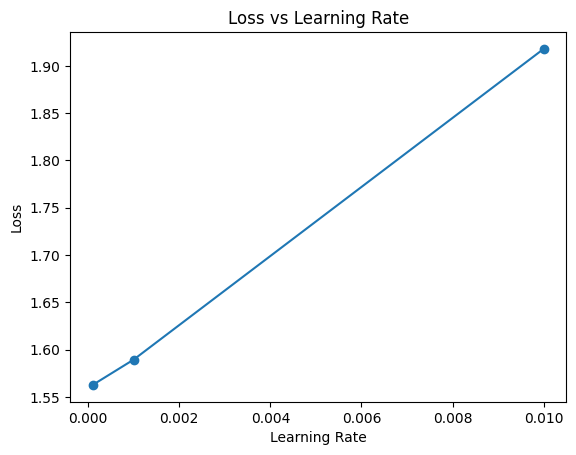

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
import numpy as np

# Load dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Flatten images for MLP
X_train = X_train.reshape(-1, 32*32*3)
X_test = X_test.reshape(-1, 32*32*3)

learning_rates = [0.0001, 0.001, 0.01]
loss_results = []

for lr in learning_rates:
    print(f"\nTraining with LR = {lr}")

    model = models.Sequential([
        layers.Dense(128, activation='relu', input_shape=(3072,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test), verbose=0)

    loss_results.append(history.history['loss'][-1])

# Plot graph
plt.plot(learning_rates, loss_results, marker='o')
plt.title("Loss vs Learning Rate")
plt.xlabel("Learning Rate")
plt.ylabel("Loss")
plt.show()


Training with LR = 0.0001

Training with LR = 0.001

Training with LR = 0.01


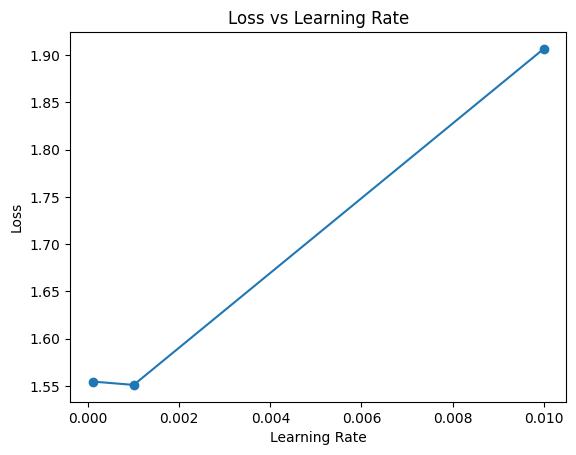

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
import numpy as np

# Load dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Flatten images for MLP
X_train = X_train.reshape(-1, 32*32*3)
X_test = X_test.reshape(-1, 32*32*3)

learning_rates = [0.0001, 0.001, 0.01]
loss_results = []

for lr in learning_rates:
    print(f"\nTraining with LR = {lr}")

    model = models.Sequential([
        layers.Dense(128, activation='relu', input_shape=(3072,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test), verbose=0)

    loss_results.append(history.history['loss'][-1])

# Plot graph
plt.plot(learning_rates, loss_results, marker='o')
plt.title("Loss vs Learning Rate")
plt.xlabel("Learning Rate")
plt.ylabel("Loss")
plt.show()

In [3]:
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Try different learning rates
for lr in [0.001, 0.01, 0.1]:
    model = Perceptron(eta0=lr, max_iter=1000)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    print(f"LR={lr}, Accuracy={accuracy_score(y_test, y_pred)}")

LR=0.001, Accuracy=0.8
LR=0.01, Accuracy=0.9333333333333333
LR=0.1, Accuracy=0.9333333333333333


In [6]:
from tensorflow.keras.datasets import cifar10
from tensorflow.keras import layers, models

# Reload dataset (IMPORTANT FIX)
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Flatten
X_train = X_train.reshape(-1, 3072)
X_test = X_test.reshape(-1, 3072)

# Try different neurons
for neurons in [64, 128, 256]:
    print(f"\nNeurons: {neurons}")

    model = models.Sequential([
        layers.Input(shape=(3072,)),   #  FIX warning also
        layers.Dense(neurons, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    model.fit(X_train, y_train, epochs=5,
              validation_data=(X_test, y_test),
              verbose=0)


Neurons: 64

Neurons: 128

Neurons: 256


In [5]:
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

model = models.Sequential([
    layers.Dense(256, activation='relu', input_shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9395 - loss: 0.2058 - val_accuracy: 0.9636 - val_loss: 0.1136
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9736 - loss: 0.0833 - val_accuracy: 0.9731 - val_loss: 0.0892
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9816 - loss: 0.0573 - val_accuracy: 0.9759 - val_loss: 0.0810
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9854 - loss: 0.0448 - val_accuracy: 0.9768 - val_loss: 0.0776
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9884 - loss: 0.0352 - val_accuracy: 0.9802 - val_loss: 0.0641
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9904 - loss: 0.0286 - val_accuracy: 0.9807 - val_loss: 0.0729
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9923 - loss: 0.0229 - val_accuracy: 0.9798 - val_loss: 0.0830
Epoch 8/10
1875/1875 ━━━━━━━━━━━

Effect of Learning Rate:
A low learning rate results in slow convergence but stable training.
A high learning rate speeds up training but may cause instability or divergence.
An optimal learning rate provides the best balance between speed and accuracy.


Gradient Descent Performance:
The MLP trained using Stochastic Gradient Descent (SGD) converges more slowly compared to adaptive optimizers like Adam.
However, SGD provides more stable and controlled updates.


Perceptron on IRIS Dataset:
The performance of the perceptron depends heavily on the learning rate.
Smaller learning rates give stable results, while larger values may lead to oscillations.
Proper tuning of parameters like max_iter and eta0 improves accuracy.


MLP on CIFAR-10 Dataset:
Increasing the number of neurons and layers improves the model’s ability to learn complex patterns.
However, too many neurons increase computation time and risk of overfitting.
MLP performs moderately on CIFAR-10 since it does not capture spatial features effectively.


MLP on MNIST Dataset:
MLP performs very well on MNIST due to simpler and structured data.
Proper selection of hidden layers and neurons significantly improves accuracy.
Overall Conclusion:
Model performance depends on proper tuning of learning rate, number of neurons, and iterations.
For image datasets like CIFAR-10, CNN models perform better than MLP because they preserve spatial information.